# Clean BSARD Corpus - Analysis Notebook

Companion analysis for `output/bsard_corpus_clean.db` (28,817 rows).
The clean dataset is the Phase-A-only, deduplicated slice of the main corpus
(`output/bsard_corpus.db`, 40,231 rows). See `CLEAN_DATASET.md` for the build rules.

Run top-to-bottom. Part 0 is a parametric deep-dive cell: change the variables and
re-run that single cell without re-running the whole notebook.


## Setup - imports, paths, DB connection, helpers

In [1]:
import json
import sqlite3
from pathlib import Path
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10


In [2]:
# Resolve project root. Notebooks do not expose __file__, so anchor on cwd
# and walk up until we see the clean DB.
def _find_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "output" / "bsard_corpus_clean.db").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate project root containing output/bsard_corpus_clean.db."
    )

PROJECT_ROOT = _find_project_root()
CLEAN_DB    = PROJECT_ROOT / "output" / "bsard_corpus_clean.db"
MAIN_DB     = PROJECT_ROOT / "output" / "bsard_corpus.db"
EXTRACTED_DIR = PROJECT_ROOT / "output" / "extracted"

assert CLEAN_DB.exists(), f"Missing {CLEAN_DB}"
assert MAIN_DB.exists(), f"Missing {MAIN_DB}"
assert EXTRACTED_DIR.exists(), f"Missing {EXTRACTED_DIR}"

print("Project root :", PROJECT_ROOT)
print("Clean DB     :", CLEAN_DB)
print("Main DB      :", MAIN_DB)
print("Extracted dir:", EXTRACTED_DIR)


Project root : C:\Users\pasch\Python Projects\Thesis Code\Dataset_Creation
Clean DB     : C:\Users\pasch\Python Projects\Thesis Code\Dataset_Creation\output\bsard_corpus_clean.db
Main DB      : C:\Users\pasch\Python Projects\Thesis Code\Dataset_Creation\output\bsard_corpus.db
Extracted dir: C:\Users\pasch\Python Projects\Thesis Code\Dataset_Creation\output\extracted


### Open the clean DB and attach the main corpus

The clean DB is the **default** connection; the full main corpus is attached under the alias
`corpus` (SQLite reserves `main` for the currently-open database, so the alias used in
`CLEAN_DATASET.md` does not work from Python). References in SQL throughout the notebook
are therefore `articles` (clean) and `corpus.articles` / `corpus.questions` / `corpus.citation_graph`.


In [3]:
conn = sqlite3.connect(str(CLEAN_DB))
conn.execute(f"ATTACH '{MAIN_DB.as_posix()}' AS corpus")

def q(sql, params=()):
    """Read a SQL query into a DataFrame."""
    return pd.read_sql(sql, conn, params=params)

clean_count = conn.execute("SELECT COUNT(*) FROM articles").fetchone()[0]
main_count  = conn.execute("SELECT COUNT(*) FROM corpus.articles").fetchone()[0]
print(f"clean.articles       : {clean_count:,} rows")
print(f"corpus.articles      : {main_count:,} rows")
print(f"corpus.questions     : {conn.execute('SELECT COUNT(*) FROM corpus.questions').fetchone()[0]:,}")
print(f"corpus.citation_graph: {conn.execute('SELECT COUNT(*) FROM corpus.citation_graph').fetchone()[0]:,}")


clean.articles       : 28,817 rows
corpus.articles      : 40,231 rows
corpus.questions     : 1,108
corpus.citation_graph: 27,712


### Helper functions

- `get_pdf_extracted_text(pdf_filename, article_number)` - pulls the raw PDF-extracted
  text from `output/extracted/*.jsonl` with the same dedup rule used to build the clean DB.
- `get_article(article_id)` - single-row lookup from the clean DB.
- `get_questions_for(article_id)` - all BSARD questions whose ground-truth contains this article.
- `get_citations_for(article_id)` - outgoing + incoming citation edges, joined back to article metadata.
- `format_article(row, truncate=500, full_text=False)` - pretty-printer for deep-dive output.


In [4]:
_PDF_JSONL_CACHE: dict[str, list[dict]] = {}

def _load_extracted(pdf_filename: str) -> list[dict]:
    """Lazy-load and memoise one extracted JSONL file keyed by pdf_filename."""
    if pdf_filename in _PDF_JSONL_CACHE:
        return _PDF_JSONL_CACHE[pdf_filename]
    stem = Path(pdf_filename).stem
    path = EXTRACTED_DIR / f"{stem}.jsonl"
    if not path.exists():
        _PDF_JSONL_CACHE[pdf_filename] = []
        return []
    records = []
    with path.open(encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                pass
    _PDF_JSONL_CACHE[pdf_filename] = records
    return records

def get_pdf_extracted_text(pdf_filename, article_number) -> str | None:
    """Return the raw PDF-extracted text for (pdf_filename, article_number).

    Applies the same dedup rule used to build the clean DB:
      1. Prefer records with non-empty article_text.
      2. Prefer the later pdf_page_start (body after TOC).
    Returns None if no matching record exists or none have text.
    """
    if pdf_filename is None or article_number is None:
        return None
    records = _load_extracted(pdf_filename)
    candidates = [r for r in records if r.get("article_number") == article_number]
    if not candidates:
        return None
    def score(rec):
        text = rec.get("article_text") or ""
        page = rec.get("pdf_page_start") or -1
        return (1 if text else 0, page)
    candidates.sort(key=score, reverse=True)
    top = candidates[0]
    text = top.get("article_text")
    return text if text else None


In [5]:
def get_article(article_id: int) -> pd.Series:
    df = q("SELECT * FROM articles WHERE article_id = ?", (int(article_id),))
    if df.empty:
        raise KeyError(f"article_id {article_id} not in clean DB")
    return df.iloc[0]

def get_questions_for(article_id: int) -> pd.DataFrame:
    sql = """
        SELECT q.question_id, q.question_text, q.split, q.n_relevant_articles
        FROM corpus.questions AS q,
             json_each(q.relevant_article_ids) AS rel
        WHERE CAST(rel.value AS INTEGER) = ?
        ORDER BY q.question_id
    """
    return q(sql, (int(article_id),))

def get_citations_for(article_id: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    outgoing = q(
        """
        SELECT e.edge_id, e.target_id AS other_article_id, e.citation_text, e.resolved,
               a.article_number AS other_article_number, a.law_code AS other_law_code,
               a.is_bsard_article AS other_is_bsard
        FROM corpus.citation_graph AS e
        LEFT JOIN articles AS a ON a.article_id = e.target_id
        WHERE e.source_id = ?
        ORDER BY e.edge_id
        """,
        (int(article_id),),
    )
    incoming = q(
        """
        SELECT e.edge_id, e.source_id AS other_article_id, e.citation_text, e.resolved,
               a.article_number AS other_article_number, a.law_code AS other_law_code,
               a.is_bsard_article AS other_is_bsard
        FROM corpus.citation_graph AS e
        LEFT JOIN articles AS a ON a.article_id = e.source_id
        WHERE e.target_id = ?
        ORDER BY e.edge_id
        """,
        (int(article_id),),
    )
    return outgoing, incoming


In [6]:
def _trim(text, truncate: int, full_text: bool) -> str:
    if text is None:
        return "<NULL>"
    if full_text or len(text) <= truncate:
        return text
    return text[:truncate] + f"\n... [truncated, {len(text) - truncate:,} chars cut]"

def format_article(row, truncate: int = 500, full_text: bool = False) -> None:
    """Pretty-print one article: metadata, text(s), associated questions, citations."""
    bar = "=" * 88
    print(bar)
    print(f"article_id          : {row['article_id']}")
    print(f"bsard_id            : {row['bsard_id']}")
    print(f"is_bsard_article    : {row['is_bsard_article']}")
    print(f"law_code            : {row['law_code']}")
    print(f"law_type            : {row['law_type']}")
    print(f"article_number      : {row['article_number']}")
    print(f"article_status      : {row['article_status']}")
    print(f"is_pre_bsard        : {row['is_pre_bsard']}")
    print(f"amendment_date      : {row['amendment_date']}")
    print(f"pdf_filename        : {row['pdf_filename']}")
    print(f"pdf_page_start..end : {row['pdf_page_start']} .. {row['pdf_page_end']}")
    try:
        hp = json.loads(row["hierarchy_path"]) if row["hierarchy_path"] else None
    except (TypeError, json.JSONDecodeError):
        hp = row["hierarchy_path"]
    print(f"hierarchy_path      : {hp}")
    print(f"numac               : {row['numac']}")
    print(f"article_text_source : {row['article_text_source']}")
    print(f"token_count         : {row['token_count']}  char_count: {row['char_count']}")

    print("-" * 88)
    if row["is_bsard_article"] == 1:
        print("[BSARD canonical text - from HuggingFace dataset, stored in article_text]")
        print(_trim(row["article_text"], truncate, full_text))
        print()
        pdf_text = get_pdf_extracted_text(row["pdf_filename"], row["article_number"])
        print("[PDF-extracted text - from output/extracted/*.jsonl]")
        if pdf_text is None:
            print("<no PDF-extracted text found for this (pdf_filename, article_number) pair>")
        else:
            print(_trim(pdf_text, truncate, full_text))
    else:
        print("[PDF-extracted text - stored in article_text]")
        print(_trim(row["article_text"], truncate, full_text))

    if row["is_bsard_article"] == 1:
        print("-" * 88)
        qdf = get_questions_for(int(row["article_id"]))
        print(f"[Associated BSARD questions: {len(qdf)}]")
        if not qdf.empty:
            display_cols = ["question_id", "split", "n_relevant_articles", "question_text"]
            shown = qdf[display_cols].copy()
            shown["question_text"] = shown["question_text"].str.slice(0, 180)
            print(shown.to_string(index=False))

    out_df, in_df = get_citations_for(int(row["article_id"]))
    print("-" * 88)
    print(f"[Outgoing citations: {len(out_df)} | Incoming citations: {len(in_df)}]")
    if not out_df.empty:
        print("Outgoing (first 15):")
        print(out_df.head(15).to_string(index=False))
    if not in_df.empty:
        print("Incoming (first 15):")
        print(in_df.head(15).to_string(index=False))
    print(bar)
    print()


## Part 0 - Parametric deep-dive cell

Edit the variables in the **first** cell below and re-run that single cell. Supported modes:

| mode | Inputs | Behaviour |
|---|---|---|
| `"pdf"` | `pdf_filename`, `sample_n=5` | Random `sample_n` BSARD + `sample_n` non-BSARD from that PDF |
| `"law_code"` | `law_code`, `sample_n=5` | Random `sample_n` BSARD + `sample_n` non-BSARD from that law code |
| `"bsard_id"` | `bsard_id` | Single article lookup |
| `"article_id"` | `article_id` | Single article lookup |
| `"question_id"` | `question_id` | Show question + all ground-truth articles, flagging any absent from clean |

`random_seed` makes the sampling modes reproducible. Set `full_text=True` to disable truncation.


In [7]:
# -------- deep-dive parameters (edit freely, then re-run THIS cell) --------
mode          = "law_code"          # "pdf" | "law_code" | "bsard_id" | "article_id" | "question_id"
pdf_filename  = "img_l_pdf_1804_03_21_1804032150_F.pdf"
law_code      = "Code Civil"
bsard_id      = 889
article_id    = 1
question_id   = 1
sample_n      = 3
random_seed   = 42
truncate      = 500
full_text     = False
# --------------------------------------------------------------------------

def _sample_group(df: pd.DataFrame, n: int, label: str) -> None:
    if df.empty:
        print(f"[{label}] no rows in scope\n")
        return
    k = min(n, len(df))
    sampled = df.sample(n=k, random_state=random_seed)
    print(f"\n######## {label}: showing {k} of {len(df)} matching rows ########\n")
    for _, row in sampled.iterrows():
        format_article(row, truncate=truncate, full_text=full_text)

def _run_pdf(pdf_filename: str) -> None:
    scope = q("SELECT * FROM articles WHERE pdf_filename = ?", (pdf_filename,))
    if scope.empty:
        print(f"No rows in clean DB for pdf_filename={pdf_filename!r}")
        return
    print(f"=== PDF deep-dive: {pdf_filename} ({len(scope)} clean rows) ===")
    _sample_group(scope[scope.is_bsard_article == 1], sample_n, "BSARD articles from this PDF")
    _sample_group(scope[scope.is_bsard_article == 0], sample_n, "Non-BSARD articles from this PDF")

def _run_law_code(law_code: str) -> None:
    scope = q("SELECT * FROM articles WHERE law_code = ?", (law_code,))
    if scope.empty:
        print(f"No rows in clean DB for law_code={law_code!r}")
        return
    n_pdfs = scope["pdf_filename"].nunique()
    print(f"=== Law-code deep-dive: {law_code} ({len(scope)} clean rows across {n_pdfs} PDF(s)) ===")
    _sample_group(scope[scope.is_bsard_article == 1], sample_n, f"BSARD articles in {law_code}")
    _sample_group(scope[scope.is_bsard_article == 0], sample_n, f"Non-BSARD articles in {law_code}")

def _run_bsard_id(bsard_id: int) -> None:
    df = q("SELECT * FROM articles WHERE bsard_id = ?", (int(bsard_id),))
    if df.empty:
        print(f"bsard_id={bsard_id} is NOT in the clean DB (one of the 5,944 Phase-A misses).")
        return
    print(f"=== bsard_id deep-dive: {bsard_id} ===")
    for _, row in df.iterrows():
        format_article(row, truncate=truncate, full_text=full_text)

def _run_article_id(article_id: int) -> None:
    try:
        row = get_article(int(article_id))
    except KeyError as err:
        print(err)
        return
    print(f"=== article_id deep-dive: {article_id} ===")
    format_article(row, truncate=truncate, full_text=full_text)

def _run_question_id(question_id: int) -> None:
    qrow = q(
        "SELECT question_id, question_text, split, n_relevant_articles, relevant_article_ids "
        "FROM corpus.questions WHERE question_id = ?",
        (int(question_id),),
    )
    if qrow.empty:
        print(f"question_id={question_id} not found in corpus.questions")
        return
    row = qrow.iloc[0]
    rel_ids = json.loads(row["relevant_article_ids"])
    print("=" * 88)
    print(f"question_id         : {row['question_id']}")
    print(f"split               : {row['split']}")
    print(f"n_relevant_articles : {row['n_relevant_articles']}  (total in main corpus)")
    print(f"question_text       :\n{row['question_text']}")
    print("=" * 88)

    if not rel_ids:
        print("No ground-truth articles attached to this question.")
        return
    placeholders = ",".join("?" * len(rel_ids))
    present = q(
        f"SELECT article_id FROM articles WHERE article_id IN ({placeholders})",
        tuple(int(x) for x in rel_ids),
    )
    present_set = set(present["article_id"].tolist())
    absent = [a for a in rel_ids if a not in present_set]
    print(f"Ground-truth articles present in clean DB: {len(present_set)} / {len(rel_ids)}")
    if absent:
        print(f"ABSENT from clean DB (Phase-A misses): {absent[:30]}" + (" ..." if len(absent) > 30 else ""))
    print()
    for aid in rel_ids:
        if aid in present_set:
            format_article(get_article(aid), truncate=truncate, full_text=full_text)
        else:
            print(f"[article_id={aid} absent from clean DB - skipping]")

_dispatch = {
    "pdf":         lambda: _run_pdf(pdf_filename),
    "law_code":    lambda: _run_law_code(law_code),
    "bsard_id":    lambda: _run_bsard_id(bsard_id),
    "article_id":  lambda: _run_article_id(article_id),
    "question_id": lambda: _run_question_id(question_id),
}
if mode not in _dispatch:
    raise ValueError(f"mode must be one of {sorted(_dispatch)}, got {mode!r}")
_dispatch[mode]()


=== Law-code deep-dive: Code Civil (2800 clean rows across 6 PDF(s)) ===

######## BSARD articles in Code Civil: showing 3 of 2229 matching rows ########

article_id          : 135
bsard_id            : 890.0
is_bsard_article    : 1
law_code            : Code Civil
law_type            : federal
article_number      : 2
article_status      : PRE_BSARD
is_pre_bsard        : 1.0
amendment_date      : 2019-03-31
pdf_filename        : img_l_pdf_1804_03_21_1804032150_F.pdf
pdf_page_start..end : 10 .. 10
hierarchy_path      : ['TITRE XI. - [1 De la majorité et des personnes protégées]1', 'CHAPITRE III.', 'Art. 2']
numac               : 1804032150
article_text_source : bsard_dataset
token_count         : 32.0  char_count: 116
----------------------------------------------------------------------------------------
[BSARD canonical text - from HuggingFace dataset, stored in article_text]
On ne peut déroger, par des conventions particulières, aux lois qui intéressent l'ordre public et les bonnes m

## Part 1 - BSARD articles **present in** the clean dataset (73.7% of the benchmark)

The clean dataset covers 16,689 of the 22,633 benchmark BSARD articles. This part
profiles that coverage per law code, how it damages question-level ground-truth
availability, and the BSARD-only metadata (status, amendment dates, law type)
of the covered slice.


BSARD benchmark total     : 22,633
Present in clean dataset  : 16,689  (73.7%)
Absent from clean dataset : 5,944  (26.3%)


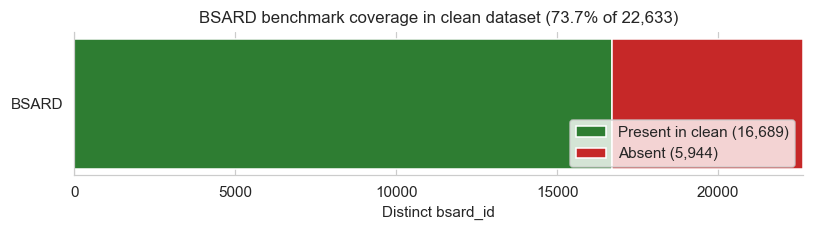

In [8]:
bsard_in_clean = conn.execute(
    "SELECT COUNT(DISTINCT bsard_id) FROM articles WHERE bsard_id IS NOT NULL"
).fetchone()[0]
bsard_in_main = conn.execute(
    "SELECT COUNT(DISTINCT bsard_id) FROM corpus.articles WHERE bsard_id IS NOT NULL"
).fetchone()[0]
bsard_absent = bsard_in_main - bsard_in_clean

print(f"BSARD benchmark total     : {bsard_in_main:,}")
print(f"Present in clean dataset  : {bsard_in_clean:,}  ({bsard_in_clean/bsard_in_main:.1%})")
print(f"Absent from clean dataset : {bsard_absent:,}  ({bsard_absent/bsard_in_main:.1%})")

fig, ax = plt.subplots(figsize=(7.5, 2.2))
ax.barh(["BSARD"], [bsard_in_clean], color="#2e7d32", label=f"Present in clean ({bsard_in_clean:,})")
ax.barh(["BSARD"], [bsard_absent], left=[bsard_in_clean], color="#c62828",
        label=f"Absent ({bsard_absent:,})")
ax.set_xlabel("Distinct bsard_id")
ax.set_title(f"BSARD benchmark coverage in clean dataset ({bsard_in_clean/bsard_in_main:.1%} of {bsard_in_main:,})")
ax.legend(loc="lower right")
ax.set_xlim(0, bsard_in_main)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout(); plt.show()


### Per-law-code BSARD coverage rate

In [9]:
per_code = q(
    """
    SELECT m.law_code AS law_code,
           COUNT(DISTINCT m.bsard_id) AS main_bsard,
           (SELECT COUNT(DISTINCT c.bsard_id)
              FROM articles AS c
             WHERE c.law_code = m.law_code AND c.bsard_id IS NOT NULL) AS clean_bsard
      FROM corpus.articles AS m
     WHERE m.bsard_id IS NOT NULL
     GROUP BY m.law_code
    """
)
per_code["coverage_rate"] = per_code["clean_bsard"] / per_code["main_bsard"]
per_code = per_code.sort_values("coverage_rate", ascending=False).reset_index(drop=True)
print(f"Law codes with <50% coverage: "
      f"{(per_code.coverage_rate < 0.5).sum()} of {len(per_code)}")
per_code


Law codes with <50% coverage: 8 of 34


,law_code,main_bsard,clean_bsard,coverage_rate
0,La Constitution,208,208,1.000000
1,Code Bruxellois du Logement,279,279,1.000000
2,Code de la Fonction Publique Wallonne,597,597,1.000000
3,Code de Droit International Privé,135,135,1.000000
4,Code Réglementaire Wallon de l'Action sociale et de la Santé,2618,2608,0.996180
5,Code de Droit Economique,2032,2019,0.993602
6,Code Electoral,218,216,0.990826
7,Code Ferroviaire,260,257,0.988462
8,Code Pénal,689,680,0.986938
9,Code Wallon de l'Action sociale et de la Santé,1032,1017,0.985465


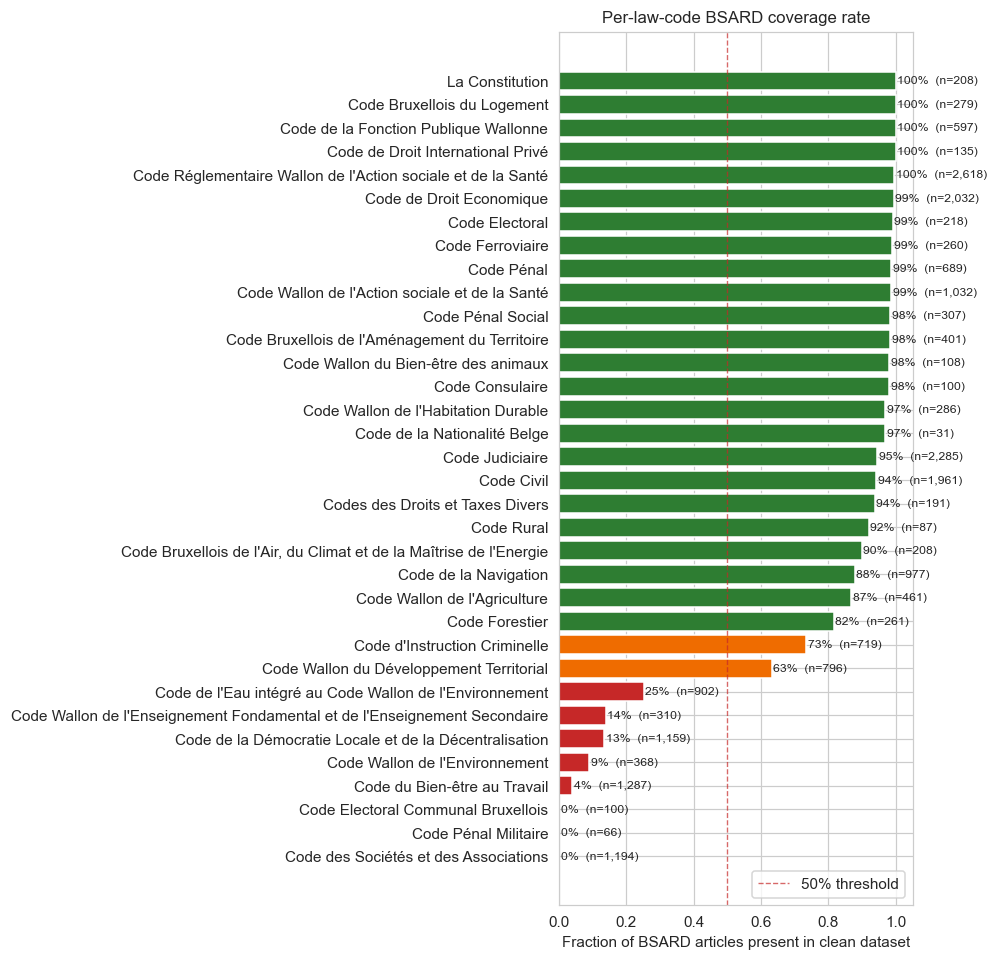

In [10]:
fig, ax = plt.subplots(figsize=(9, max(5, 0.26 * len(per_code))))
colors = ["#c62828" if r < 0.5 else ("#ef6c00" if r < 0.8 else "#2e7d32")
          for r in per_code["coverage_rate"]]
ax.barh(per_code["law_code"], per_code["coverage_rate"], color=colors)
ax.axvline(0.5, color="#c62828", ls="--", lw=0.9, alpha=0.7, label="50% threshold")
ax.set_xlabel("Fraction of BSARD articles present in clean dataset")
ax.set_xlim(0, 1.05)
ax.invert_yaxis()
ax.set_title("Per-law-code BSARD coverage rate")
for i, (rate, main_n) in enumerate(zip(per_code["coverage_rate"], per_code["main_bsard"])):
    ax.text(rate + 0.005, i, f"{rate:.0%}  (n={main_n:,})", va="center", fontsize=8)
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()


### The 5,944 missing BSARD IDs - grouped by law code

In [11]:
missing = q(
    """
    SELECT m.bsard_id, m.law_code, m.article_number
      FROM corpus.articles AS m
     WHERE m.is_bsard_article = 1
       AND m.article_id NOT IN (SELECT article_id FROM articles)
    """
)

missing_unique = missing.drop_duplicates("bsard_id")
print(f"Distinct missing BSARD ids: {len(missing_unique):,}")
missing_by_code = (missing_unique.groupby("law_code").size()
                     .sort_values(ascending=False)
                     .rename("n_missing")
                     .reset_index())
print("\nTop 10 law codes by count of missing BSARD articles:")
missing_by_code.head(10)


Distinct missing BSARD ids: 9,095

Top 10 law codes by count of missing BSARD articles:


,law_code,n_missing
0,Code du Bien-être au Travail,1272
1,Code des Sociétés et des Associations,1194
2,Code de la Démocratie Locale et de la Décentralisation,1113
3,Code de l'Eau intégré au Code Wallon de l'Environnement,694
4,Code Wallon du Développement Territorial,649
5,Code Réglementaire Wallon de l'Action sociale et de la Santé,514
6,Code Judiciaire,397
7,Code Wallon de l'Environnement,339
8,Code de Droit Economique,318
9,Code Wallon de l'Enseignement Fondamental et de l'Enseignement Secondaire,278


### Question-level ground-truth coverage

Total BSARD questions      : 1,108
  100% ground-truth covered: 576   (52.0%)
  partial coverage         : 411   (37.1%)
    0% coverage            : 121   (10.9%)


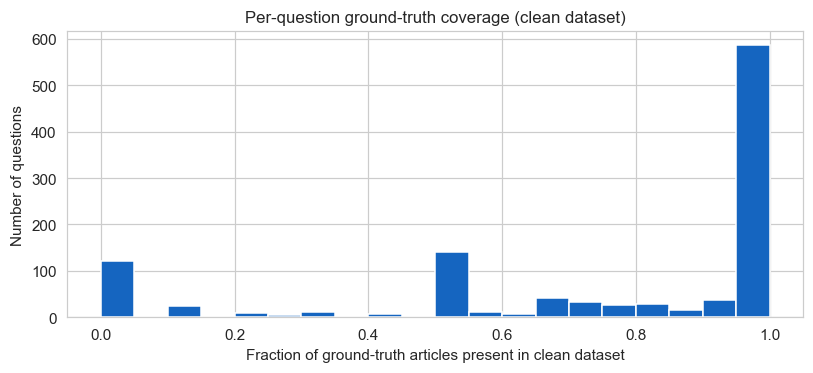

In [12]:
questions = q("SELECT question_id, question_text, split, n_relevant_articles, relevant_article_ids FROM corpus.questions")
clean_ids = set(
    r[0] for r in conn.execute("SELECT article_id FROM articles").fetchall()
)

def _q_coverage(row):
    rel = json.loads(row["relevant_article_ids"])
    if not rel:
        return pd.Series({"n_relevant": 0, "n_present": 0, "coverage": np.nan})
    n_present = sum(1 for a in rel if a in clean_ids)
    return pd.Series({
        "n_relevant": len(rel),
        "n_present": n_present,
        "coverage":  n_present / len(rel),
    })

qcov = pd.concat([questions, questions.apply(_q_coverage, axis=1)], axis=1)

n_total    = len(qcov)
n_full     = int((qcov.coverage == 1.0).sum())
n_zero     = int((qcov.coverage == 0.0).sum())
n_partial  = n_total - n_full - n_zero
print(f"Total BSARD questions      : {n_total:,}")
print(f"  100% ground-truth covered: {n_full:,}   ({n_full/n_total:.1%})")
print(f"  partial coverage         : {n_partial:,}   ({n_partial/n_total:.1%})")
print(f"    0% coverage            : {n_zero:,}   ({n_zero/n_total:.1%})")

fig, ax = plt.subplots(figsize=(7.5, 3.5))
ax.hist(qcov["coverage"].dropna(), bins=np.linspace(0, 1, 21),
        color="#1565c0", edgecolor="white")
ax.set_xlabel("Fraction of ground-truth articles present in clean dataset")
ax.set_ylabel("Number of questions")
ax.set_title("Per-question ground-truth coverage (clean dataset)")
plt.tight_layout(); plt.show()


In [13]:
worst = qcov.sort_values(["coverage", "n_relevant"]).head(10)[
    ["question_id", "split", "n_relevant", "n_present", "coverage", "question_text"]
].copy()
worst["question_text"] = worst["question_text"].str.slice(0, 140) + "..."
print("Worst 10 questions by ground-truth coverage:")
worst


Worst 10 questions by ground-truth coverage:


,question_id,split,n_relevant,n_present,coverage,question_text
14,15,train,1.0,0.0,0.0,Je suis locataire. Dois-je installer des détecteurs incendie en Wallonie ?...
19,20,train,1.0,0.0,0.0,Je suis propriétaire. Dois-je installer des détecteurs incendie en Wallonie ?...
20,21,train,1.0,0.0,0.0,Je suis propriétaire. Dois-je installer des détecteurs incendie en Wallonie ?...
23,24,train,1.0,0.0,0.0,Après combien de temps ma dette de contribution alimentaire est-elle prescrite ?...
32,33,train,1.0,0.0,0.0,"Je ne paie pas mon stationnement, vais-je recevoir une amende pénale ?..."
33,34,train,1.0,0.0,0.0,Après combien de temps ma facture d'eau est-elle prescrite à Bruxelles ?...
35,36,train,1.0,0.0,0.0,Après combien de temps ma facture d'eau est-elle prescrite en Wallonie ?...
39,40,test,1.0,0.0,0.0,Comment contester ma facture d'eau en Wallonie ?...
40,41,train,1.0,0.0,0.0,Après combien de temps ma facture de gaz et d'électricité est-elle prescrite à Bruxelles ?...
41,42,train,1.0,0.0,0.0,Après combien de temps ma facture de gaz et d'électricité est-elle prescrite en Wallonie ?...


### `article_status` / `amendment_date` / `law_type` breakdown

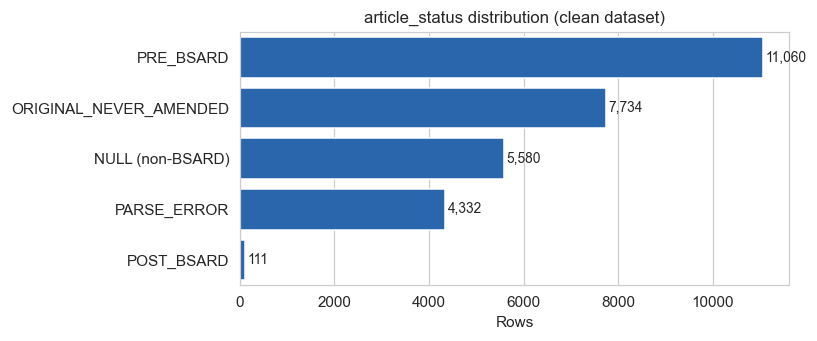

,article_status,n
0,PRE_BSARD,11060
1,ORIGINAL_NEVER_AMENDED,7734
2,NULL (non-BSARD),5580
3,PARSE_ERROR,4332
4,POST_BSARD,111


In [14]:
status = q(
    """
    SELECT COALESCE(article_status, 'NULL (non-BSARD)') AS article_status, COUNT(*) AS n
      FROM articles
     GROUP BY article_status
     ORDER BY n DESC
    """
)

fig, ax = plt.subplots(figsize=(7.5, 3.2))
sns.barplot(data=status, x="n", y="article_status", color="#1565c0", ax=ax)
ax.set_xlabel("Rows")
ax.set_ylabel("")
ax.set_title("article_status distribution (clean dataset)")
for p, v in zip(ax.patches, status["n"]):
    ax.text(p.get_width() + 60, p.get_y() + p.get_height()/2, f"{v:,}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

status


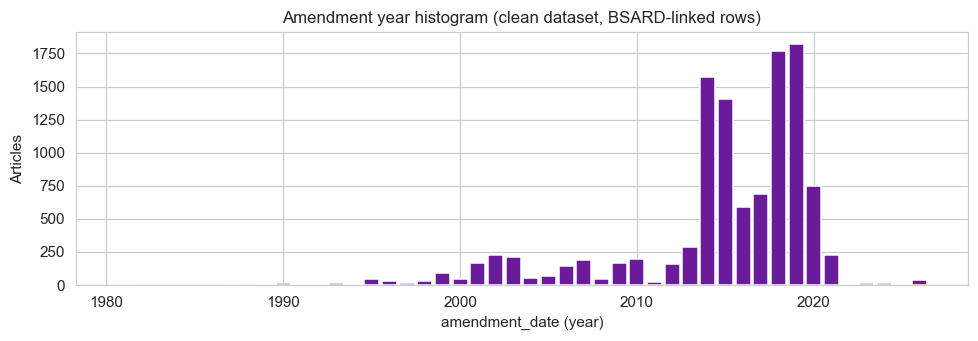

In [15]:
amd = q(
    """
    SELECT substr(amendment_date, 1, 4) AS year, COUNT(*) AS n
      FROM articles
     WHERE amendment_date IS NOT NULL
     GROUP BY year
     ORDER BY year
    """
)
amd = amd[amd["year"].str.match(r"^\d{4}$")].copy()
amd["year"] = amd["year"].astype(int)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(amd["year"], amd["n"], color="#6a1b9a", width=0.85)
ax.set_xlabel("amendment_date (year)")
ax.set_ylabel("Articles")
ax.set_title("Amendment year histogram (clean dataset, BSARD-linked rows)")
plt.tight_layout(); plt.show()


        law_type     n
         federal 14693
        regional  8544
NULL (non-BSARD)  5580


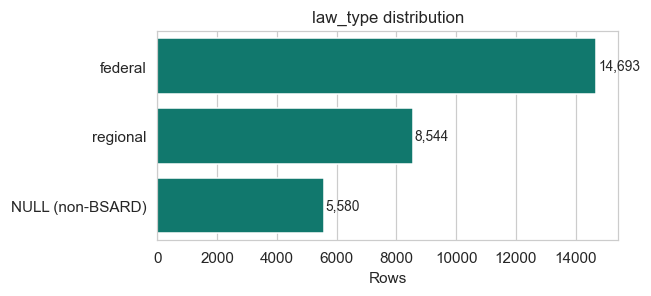

In [16]:
law_type = q(
    """
    SELECT COALESCE(law_type, 'NULL (non-BSARD)') AS law_type, COUNT(*) AS n
      FROM articles GROUP BY law_type ORDER BY n DESC
    """
)
print(law_type.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 2.8))
sns.barplot(data=law_type, x="n", y="law_type", color="#00897b", ax=ax)
ax.set_xlabel("Rows")
ax.set_ylabel("")
ax.set_title("law_type distribution")
for p, v in zip(ax.patches, law_type["n"]):
    ax.text(p.get_width() + 60, p.get_y() + p.get_height()/2, f"{v:,}", va="center", fontsize=9)
plt.tight_layout(); plt.show()


## Part 2 - PDF extraction analysis

Profiles the Phase A PDF-extraction slice: per-PDF volumes and extraction failure
rates, the text-source mix, length distributions, hierarchy depth, and the
rows that carry no `article_text` (abrogation-only entries and range headers).


### Per-PDF table

In [17]:
per_pdf = q(
    """
    SELECT c.pdf_filename,
           MIN(c.law_code)                                         AS law_code,
           COUNT(*)                                                AS n_clean,
           SUM(CASE WHEN c.is_bsard_article = 1 THEN 1 ELSE 0 END) AS n_bsard,
           SUM(CASE WHEN c.is_bsard_article = 0 THEN 1 ELSE 0 END) AS n_nonbsard,
           SUM(CASE WHEN c.article_text_source = 'pdf_extracted'       THEN 1 ELSE 0 END) AS n_pdf_extracted,
           SUM(CASE WHEN c.article_text_source = 'pdf_extraction_failed' THEN 1 ELSE 0 END) AS n_pdf_extraction_failed,
           (SELECT COUNT(*) FROM corpus.articles AS m WHERE m.pdf_filename = c.pdf_filename) AS n_rows_in_main
      FROM articles AS c
     GROUP BY c.pdf_filename
    """
)
per_pdf["duplication_ratio"] = per_pdf["n_rows_in_main"] / per_pdf["n_clean"]
per_pdf = per_pdf.sort_values("n_clean", ascending=False).reset_index(drop=True)
print(f"Total PDFs represented in clean dataset: {len(per_pdf)}")
print(f"PDFs with duplication_ratio > 1.5      : {(per_pdf.duplication_ratio > 1.5).sum()}")

def _highlight(row):
    return ["background-color: #fff3e0" if row["duplication_ratio"] > 1.5 else ""
            for _ in row]
try:
    styled = per_pdf.style.apply(_highlight, axis=1).format({"duplication_ratio": "{:.2f}"})
    display(styled)
except Exception:
    print(per_pdf)


Total PDFs represented in clean dataset: 47
PDFs with duplication_ratio > 1.5      : 8


,pdf_filename,law_code,n_clean,n_bsard,n_nonbsard,n_pdf_extracted,n_pdf_extraction_failed,n_rows_in_main,duplication_ratio
0,img_l_pdf_2013_07_04_2013A27132_F.pdf,Code Réglementaire Wallon de l'Action sociale et de la Santé,3684,3216,468,441,27,4355,1.18
1,img_l_pdf_2013_02_28_2013A11134_F.pdf,Code de Droit Economique,2766,2019,747,463,284,3188,1.15
2,img_l_pdf_2004_04_22_2004A27184_F.pdf,Code de la Démocratie Locale et de la Décentralisation,2251,2012,239,224,15,4464,1.98
3,img_l_pdf_2017_04_28_2017A10461_F.pdf,Code du Bien-être au Travail,1713,1593,120,116,4,3064,1.79
4,img_l_pdf_2011_09_29_2011A27223_F.pdf,Code Wallon de l'Action sociale et de la Santé,1478,1302,176,165,11,1811,1.23
5,img_l_pdf_2019_05_08_2019A12565_F.pdf,Code de la Navigation,1447,940,507,463,44,1613,1.11
6,img_l_pdf_1967_10_10_1967101055_F.pdf,Code Judiciaire,1119,1028,91,88,3,1275,1.14
7,img_l_pdf_1967_10_10_1967101053_F.pdf,Code Judiciaire,1020,832,188,174,14,1225,1.20
8,img_l_pdf_1867_06_08_1867060850_F.pdf,Code Pénal,971,775,196,191,5,1051,1.08
9,img_l_pdf_2016_07_20_2016A05561_F.pdf,Code Wallon du Développement Territorial,810,503,307,271,36,1612,1.99


### `article_text_source` distribution

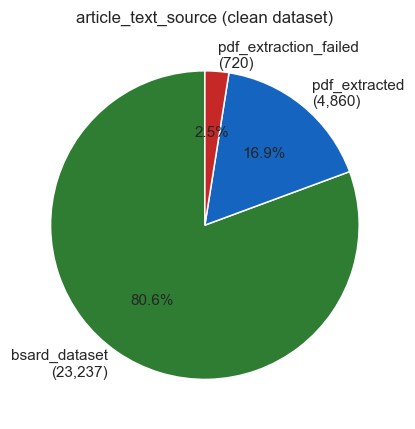

,article_text_source,n
0,bsard_dataset,23237
1,pdf_extracted,4860
2,pdf_extraction_failed,720


In [18]:
src = q("SELECT article_text_source, COUNT(*) AS n FROM articles GROUP BY article_text_source ORDER BY n DESC")

fig, ax = plt.subplots(figsize=(5.5, 4))
colors = {"bsard_dataset": "#2e7d32",
          "pdf_extracted": "#1565c0",
          "pdf_extraction_failed": "#c62828"}
ax.pie(src["n"], labels=[f"{s}\n({n:,})" for s, n in zip(src.article_text_source, src.n)],
       colors=[colors.get(s, "#9e9e9e") for s in src.article_text_source],
       autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "white"})
ax.set_title("article_text_source (clean dataset)")
plt.tight_layout(); plt.show()

src


### Text length distributions for `pdf_extracted` (non-BSARD) vs `bsard_dataset` rows

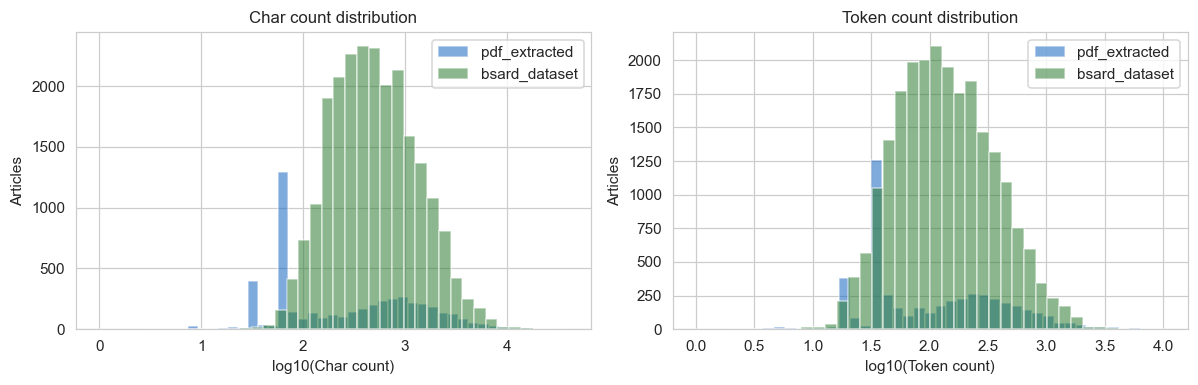

Percentiles (p5 / p25 / p50 / p75 / p95):
                    char_count                              token_count                            
                          0.05   0.25   0.50   0.75    0.95        0.05  0.25   0.50   0.75    0.95
article_text_source                                                                                
bsard_dataset            110.0  243.0  472.0  976.0  2633.0        31.0  66.0  128.0  270.0   722.2
pdf_extracted             32.0   68.0  246.5  996.0  3397.0        20.0  36.0   85.0  302.2  1007.2


In [19]:
lengths = q(
    """
    SELECT article_text_source, char_count, token_count
      FROM articles
     WHERE article_text IS NOT NULL
       AND article_text_source IN ('bsard_dataset', 'pdf_extracted')
    """
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, col, label in zip(axes, ["char_count", "token_count"], ["Char count", "Token count"]):
    for src_key, color in [("pdf_extracted", "#1565c0"), ("bsard_dataset", "#2e7d32")]:
        vals = lengths.loc[lengths.article_text_source == src_key, col]
        vals = vals[vals > 0]
        ax.hist(np.log10(vals), bins=40, alpha=0.55, color=color, label=src_key, edgecolor="white")
    ax.set_xlabel(f"log10({label})")
    ax.set_ylabel("Articles")
    ax.set_title(f"{label} distribution")
    ax.legend()
plt.tight_layout(); plt.show()

print("Percentiles (p5 / p25 / p50 / p75 / p95):")
print(lengths.groupby("article_text_source")[["char_count", "token_count"]]
           .quantile([0.05, 0.25, 0.5, 0.75, 0.95]).unstack(level=1).round(1))


### Hierarchy depth distribution

Rows with hierarchy_depth == 0 (no containing heading): 31
 article_id                          pdf_filename article_number article_text_source
          1 img_l_pdf_1804_03_21_1804032150_F.pdf            1-2       bsard_dataset
       5699 img_l_pdf_1894_04_12_1894041255_F.pdf              M       bsard_dataset
       6072 img_l_pdf_1927_03_02_1927030201_F.pdf            1-2       bsard_dataset
       6477 img_l_pdf_1967_10_10_1967101052_F.pdf           1-16       bsard_dataset
       6557 img_l_pdf_1967_10_10_1967101053_F.pdf             58       bsard_dataset
       6558 img_l_pdf_1967_10_10_1967101053_F.pdf          59-60       bsard_dataset
       6559 img_l_pdf_1967_10_10_1967101053_F.pdf          66-72       bsard_dataset
       8024 img_l_pdf_1967_10_10_1967101055_F.pdf      1235ter/4       bsard_dataset
       8025 img_l_pdf_1967_10_10_1967101055_F.pdf            664       bsard_dataset
       9774 img_l_pdf_1967_10_10_1967101064_F.pdf      1738-1747       bsard_dataset


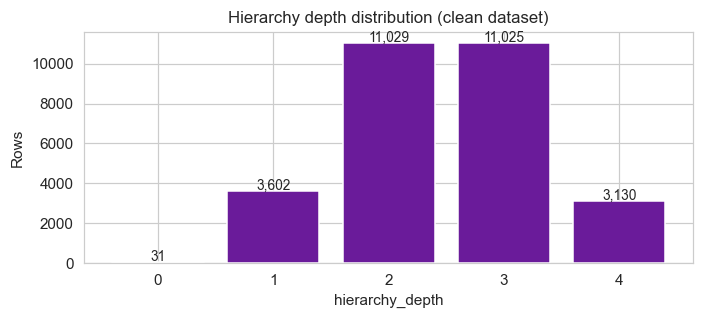

,hierarchy_depth,n
0,0,31
1,1,3602
2,2,11029
3,3,11025
4,4,3130


In [20]:
depth = q("SELECT hierarchy_depth, COUNT(*) AS n FROM articles GROUP BY hierarchy_depth ORDER BY hierarchy_depth")
depth_0 = int(depth.loc[depth.hierarchy_depth == 0, "n"].sum())
print(f"Rows with hierarchy_depth == 0 (no containing heading): {depth_0}")
if depth_0 > 0:
    depth0_preview = q("SELECT article_id, pdf_filename, article_number, article_text_source "
                       "FROM articles WHERE hierarchy_depth = 0 LIMIT 10")
    print(depth0_preview.to_string(index=False))

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.bar(depth["hierarchy_depth"].astype(str), depth["n"], color="#6a1b9a")
for i, n in enumerate(depth["n"]):
    ax.text(i, n + 60, f"{n:,}", ha="center", fontsize=9)
ax.set_xlabel("hierarchy_depth")
ax.set_ylabel("Rows")
ax.set_title("Hierarchy depth distribution (clean dataset)")
plt.tight_layout(); plt.show()

depth


### Rows with NULL `article_text` - abrogation-only and range headers

In [21]:
null_rows = q(
    """
    SELECT article_id, pdf_filename, law_code, article_number
      FROM articles
     WHERE article_text IS NULL
    """
)

def _classify(num):
    if num is None:
        return "other"
    if "_REGION" in num or "_COMMUNAUTE" in num:
        return "regional_variant"
    if "-" in num:
        return "range_header"
    return "other"

null_rows["category"] = null_rows["article_number"].map(_classify)
print(f"Total NULL-text rows in clean dataset: {len(null_rows)}")
print(null_rows["category"].value_counts().to_string())

for cat in ["range_header", "regional_variant", "other"]:
    sub = null_rows[null_rows.category == cat].head(10)
    print(f"\n--- {cat}: {len(null_rows[null_rows.category == cat])} rows ---")
    if not sub.empty:
        print(sub[["article_id", "law_code", "article_number", "pdf_filename"]].to_string(index=False))


Total NULL-text rows in clean dataset: 720
category
range_header        690
other                24
regional_variant      6

--- range_header: 690 rows ---
 article_id   law_code article_number                          pdf_filename
         49 Code Civil        172-179 img_l_pdf_1804_03_21_1804032150_F.pdf
         57 Code Civil        267-271 img_l_pdf_1804_03_21_1804032150_F.pdf
         58 Code Civil        272-274 img_l_pdf_1804_03_21_1804032150_F.pdf
       1122 Code Civil        756-766 img_l_pdf_1804_03_21_1804032152_F.pdf
       1123 Code Civil        767-773 img_l_pdf_1804_03_21_1804032152_F.pdf
       1613 Code Civil      1315-1316 img_l_pdf_1804_03_21_1804032153_F.pdf
       1614 Code Civil      1317-1321 img_l_pdf_1804_03_21_1804032153_F.pdf
       1615 Code Civil      1322-1332 img_l_pdf_1804_03_21_1804032153_F.pdf
       1618 Code Civil      1337-1340 img_l_pdf_1804_03_21_1804032153_F.pdf
       1619 Code Civil      1341-1348 img_l_pdf_1804_03_21_1804032153_F.pdf

--- reg

### Per-PDF extraction failure rate (top 10)

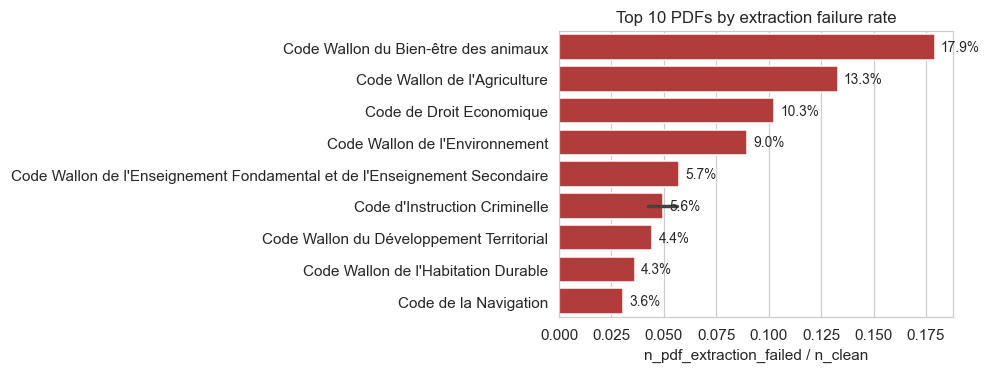

,pdf_filename,law_code,n_clean,n_pdf_extraction_failed,failure_rate
0,img_l_pdf_2018_10_04_2018A15578_F.pdf,Code Wallon du Bien-être des animaux,134,24,0.179104
1,img_l_pdf_2014_03_27_2014027151_F.pdf,Code Wallon de l'Agriculture,557,74,0.132855
2,img_l_pdf_2013_02_28_2013A11134_F.pdf,Code de Droit Economique,2766,284,0.102675
3,img_l_pdf_2004_05_27_2004A27101_F.pdf,Code Wallon de l'Environnement,401,36,0.089776
4,img_l_pdf_2019_05_03_2019A30854_F.pdf,Code Wallon de l'Enseignement Fondamental et de l'Enseignement Secondaire,716,41,0.057263
5,img_l_pdf_1808_12_16_1808121650_F.pdf,Code d'Instruction Criminelle,71,4,0.056338
6,img_l_pdf_2016_07_20_2016A05561_F.pdf,Code Wallon du Développement Territorial,810,36,0.044444
7,img_l_pdf_1808_12_12_1808121250_F.pdf,Code d'Instruction Criminelle,141,6,0.042553
8,img_l_pdf_1998_10_29_1998A27652_F.pdf,Code Wallon de l'Habitation Durable,555,20,0.036036
9,img_l_pdf_2019_05_08_2019A12565_F.pdf,Code de la Navigation,1447,44,0.030408


In [22]:
fail_rate = per_pdf.assign(
    failure_rate=lambda d: d["n_pdf_extraction_failed"] / d["n_clean"]
).sort_values("failure_rate", ascending=False)
fail_rate_top = fail_rate[[
    "pdf_filename", "law_code", "n_clean",
    "n_pdf_extraction_failed", "failure_rate",
]].head(10).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.barplot(data=fail_rate_top, x="failure_rate", y="law_code", color="#c62828", ax=ax)
ax.set_xlabel("n_pdf_extraction_failed / n_clean")
ax.set_ylabel("")
ax.set_title("Top 10 PDFs by extraction failure rate")
for p, v in zip(ax.patches, fail_rate_top["failure_rate"]):
    ax.text(p.get_width() + 0.003, p.get_y() + p.get_height()/2, f"{v:.1%}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

fail_rate_top


## Part 3 - Clean dataset statistics

Corpus-level profile: size, length distributions, citation graph (filtered to
edges where both endpoints survive into the clean DB), hierarchy coverage,
per-law-code sizes, and a cross-code citation heatmap.


### Overall counts

In [23]:
overall = q(
    """
    SELECT
      COUNT(*)                                               AS total_rows,
      SUM(CASE WHEN is_bsard_article = 1 THEN 1 ELSE 0 END)  AS n_bsard,
      SUM(CASE WHEN is_bsard_article = 0 THEN 1 ELSE 0 END)  AS n_nonbsard,
      COUNT(DISTINCT law_code)                               AS n_law_codes,
      COUNT(DISTINCT pdf_filename)                           AS n_pdfs,
      COUNT(DISTINCT bsard_id)                               AS n_bsard_ids
    FROM articles
    """
).iloc[0]
for k, v in overall.items():
    print(f"{k:18s} : {int(v):,}")


total_rows         : 28,817
n_bsard            : 23,237
n_nonbsard         : 5,580
n_law_codes        : 31
n_pdfs             : 47
n_bsard_ids        : 16,689


### Article length distributions (`char_count`, `token_count`)

Length percentiles:
     metric     group    p5   p25   p50    p75     p95
 char_count       all  68.0 210.0 454.0 979.00 2775.20
 char_count     bsard 110.0 243.0 472.0 976.00 2633.00
 char_count non_bsard  32.0  68.0 246.5 996.00 3397.05
token_count       all  28.0  58.0 126.0 273.00  764.00
token_count     bsard  31.0  66.0 128.0 270.00  722.20
token_count non_bsard  20.0  36.0  85.0 302.25 1007.15


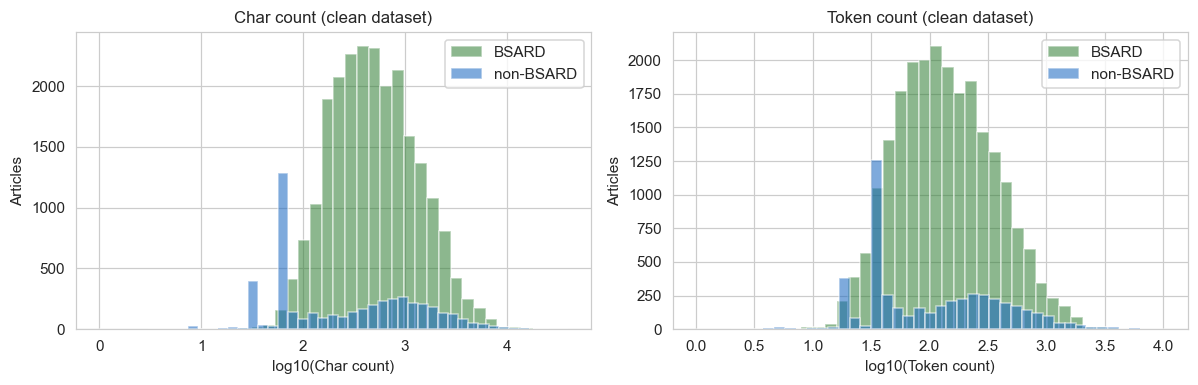

In [24]:
lens = q(
    "SELECT is_bsard_article, char_count, token_count FROM articles WHERE article_text IS NOT NULL"
)

def _pcts(series: pd.Series) -> dict:
    return {f"p{int(p*100)}": float(series.quantile(p)) for p in [0.05, 0.25, 0.5, 0.75, 0.95]}

summary_rows = []
for col in ["char_count", "token_count"]:
    summary_rows.append({"metric": col, "group": "all",       **_pcts(lens[col])})
    summary_rows.append({"metric": col, "group": "bsard",     **_pcts(lens.loc[lens.is_bsard_article == 1, col])})
    summary_rows.append({"metric": col, "group": "non_bsard", **_pcts(lens.loc[lens.is_bsard_article == 0, col])})
summary_df = pd.DataFrame(summary_rows)
print("Length percentiles:")
print(summary_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, col, label in zip(axes, ["char_count", "token_count"], ["Char count", "Token count"]):
    for grp, color, name in [(1, "#2e7d32", "BSARD"), (0, "#1565c0", "non-BSARD")]:
        vals = lens.loc[lens.is_bsard_article == grp, col]
        vals = vals[vals > 0]
        ax.hist(np.log10(vals), bins=40, alpha=0.55, color=color, label=name, edgecolor="white")
    ax.set_xlabel(f"log10({label})")
    ax.set_ylabel("Articles")
    ax.set_title(f"{label} (clean dataset)")
    ax.legend()
plt.tight_layout(); plt.show()


### Citation graph - filtered to edges with both endpoints in the clean set

Total edges                         : 14,610
Articles with >=1 outgoing edge     : 9,398  (32.6%)
Articles with >=1 incoming edge     : 4,692  (16.3%)


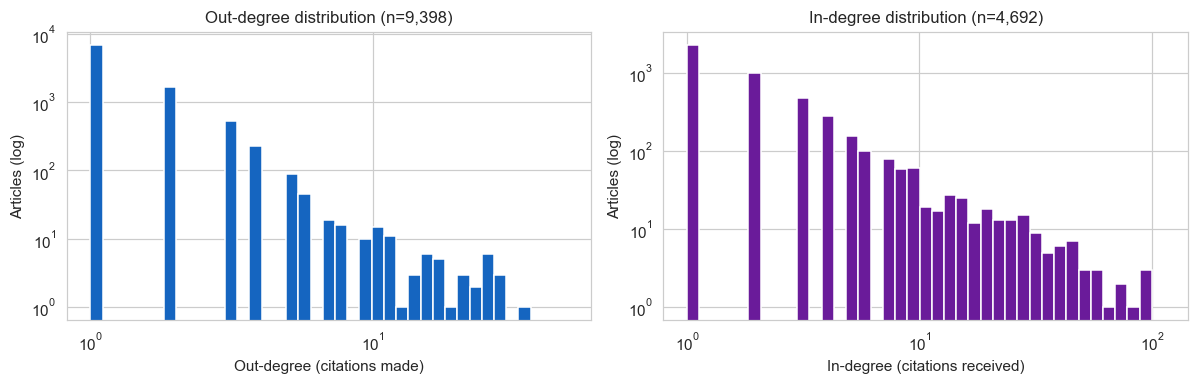

In [25]:
edges = q(
    """
    SELECT e.source_id, e.target_id
      FROM corpus.citation_graph AS e
     WHERE e.source_id IN (SELECT article_id FROM articles)
       AND e.target_id IN (SELECT article_id FROM articles)
    """
)
n_edges = len(edges)
n_articles = clean_count
n_with_out = edges["source_id"].nunique()
n_with_in  = edges["target_id"].nunique()
print(f"Total edges                         : {n_edges:,}")
print(f"Articles with >=1 outgoing edge     : {n_with_out:,}  ({n_with_out/n_articles:.1%})")
print(f"Articles with >=1 incoming edge     : {n_with_in:,}  ({n_with_in/n_articles:.1%})")

out_deg = edges.groupby("source_id").size()
in_deg  = edges.groupby("target_id").size()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(out_deg, bins=np.logspace(0, np.log10(max(out_deg.max(), 2)), 40),
             color="#1565c0", edgecolor="white")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Out-degree (citations made)")
axes[0].set_ylabel("Articles (log)")
axes[0].set_title(f"Out-degree distribution (n={len(out_deg):,})")

axes[1].hist(in_deg, bins=np.logspace(0, np.log10(max(in_deg.max(), 2)), 40),
             color="#6a1b9a", edgecolor="white")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("In-degree (citations received)")
axes[1].set_ylabel("Articles (log)")
axes[1].set_title(f"In-degree distribution (n={len(in_deg):,})")
plt.tight_layout(); plt.show()


In [26]:
top_cited_ids = in_deg.sort_values(ascending=False).head(10).reset_index()
top_cited_ids.columns = ["article_id", "in_degree"]
placeholders = ",".join("?" * len(top_cited_ids))
top_cited_meta = q(
    f"SELECT article_id, law_code, article_number, is_bsard_article FROM articles "
    f"WHERE article_id IN ({placeholders})",
    tuple(top_cited_ids["article_id"].astype(int).tolist()),
)
top_cited = top_cited_ids.merge(top_cited_meta, on="article_id", how="left").sort_values("in_degree", ascending=False)
print("Top 10 most-cited articles (edges where both endpoints are in the clean dataset):")
top_cited


Top 10 most-cited articles (edges where both endpoints are in the clean dataset):


,article_id,in_degree,law_code,article_number,is_bsard_article
0,135,113,Code Civil,2,1
1,31562,97,Code du Bien-être au Travail,VII.1-3,1
2,31636,96,Code du Bien-être au Travail,VII.1-77,1
3,6212,89,Codes des Droits et Taxes Divers,94,0
4,8874,84,Code Judiciaire,1231-1/8,1
5,31077,77,Code du Bien-être au Travail,III.5-39,1
6,192,72,Code Civil,58,1
7,6490,63,Code Judiciaire,3,1
8,151,57,Code Civil,18,1
9,785,57,Code Civil,492/1,1


### Hierarchy coverage

In [27]:
hier = q(
    """
    SELECT
      AVG(CASE WHEN chapter_title    IS NOT NULL THEN 1.0 ELSE 0.0 END) AS pct_chapter,
      AVG(CASE WHEN section_title    IS NOT NULL THEN 1.0 ELSE 0.0 END) AS pct_section,
      AVG(CASE WHEN subsection_title IS NOT NULL THEN 1.0 ELSE 0.0 END) AS pct_subsection,
      AVG(CASE WHEN law_title_text   IS NOT NULL
              AND chapter_title      IS NOT NULL
              AND section_title      IS NOT NULL
              AND subsection_title   IS NOT NULL THEN 1.0 ELSE 0.0 END) AS pct_full_4level
    FROM articles
    """
).iloc[0]
for k, v in hier.items():
    print(f"{k:17s}: {v:.1%}")


pct_chapter      : 84.0%
pct_section      : 53.7%
pct_subsection   : 12.9%
pct_full_4level  : 10.9%


### Per-law-code size table

In [28]:
sizes = q(
    """
    SELECT law_code, COUNT(*) AS n_articles,
           SUM(CASE WHEN is_bsard_article = 1 THEN 1 ELSE 0 END) AS n_bsard,
           SUM(CASE WHEN is_bsard_article = 0 THEN 1 ELSE 0 END) AS n_nonbsard
      FROM articles
     GROUP BY law_code
     ORDER BY n_articles DESC
    """
)
sizes


,law_code,n_articles,n_bsard,n_nonbsard
0,Code Réglementaire Wallon de l'Action sociale et de la Santé,3684,3216,468
1,Code Judiciaire,2946,2542,404
2,Code Civil,2800,2229,571
3,Code de Droit Economique,2766,2019,747
4,Code de la Démocratie Locale et de la Décentralisation,2251,2012,239
5,Code du Bien-être au Travail,1713,1593,120
6,Code Wallon de l'Action sociale et de la Santé,1478,1302,176
7,Code de la Navigation,1447,940,507
8,Code Pénal,971,775,196
9,Code d'Instruction Criminelle,914,589,325


### Cross-code citation flow - heatmap of top-10 law codes

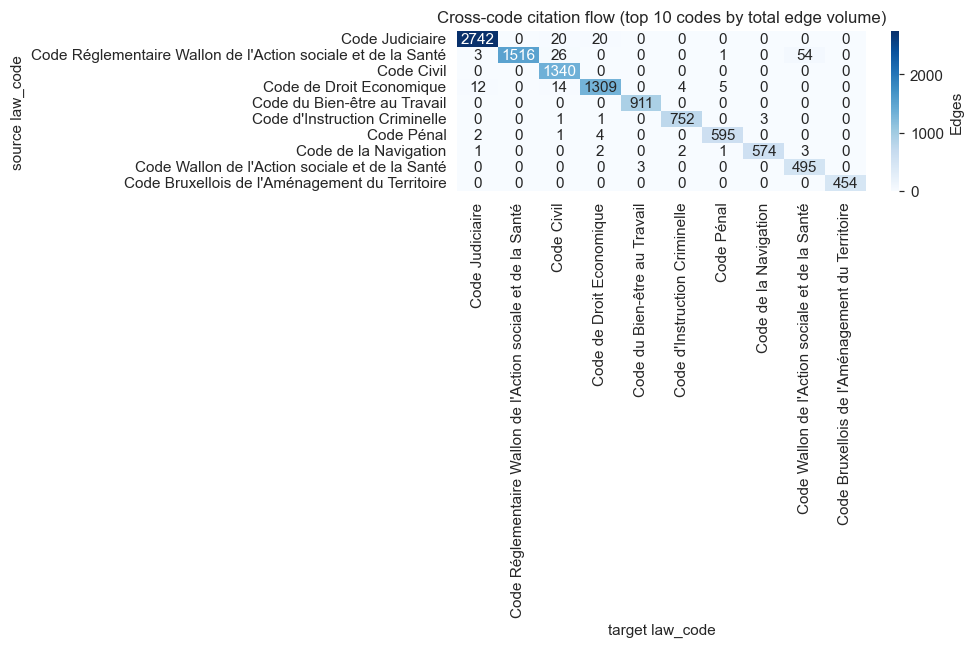

In [29]:
edge_codes = q(
    """
    SELECT a_src.law_code AS source_law_code, a_tgt.law_code AS target_law_code, COUNT(*) AS n
      FROM corpus.citation_graph AS e
      JOIN articles AS a_src ON a_src.article_id = e.source_id
      JOIN articles AS a_tgt ON a_tgt.article_id = e.target_id
     GROUP BY a_src.law_code, a_tgt.law_code
    """
)
flow = edge_codes.pivot_table(index="source_law_code", columns="target_law_code",
                              values="n", aggfunc="sum", fill_value=0)

top_codes = flow.sum(axis=1).add(flow.sum(axis=0), fill_value=0).sort_values(ascending=False).head(10).index.tolist()
flow_top = flow.reindex(index=top_codes, columns=top_codes, fill_value=0)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(flow_top, annot=True, fmt="d", cmap="Blues", cbar_kws={"label": "Edges"}, ax=ax)
ax.set_title("Cross-code citation flow (top 10 codes by total edge volume)")
ax.set_xlabel("target law_code")
ax.set_ylabel("source law_code")
plt.tight_layout(); plt.show()


---

End of notebook. `conn` remains open for ad-hoc querying; call `conn.close()` when done.
